In [1]:
#from __future__ import print_function
import yaml 
import umap
import torch
import numpy as np
import seaborn as sns
from scipy import stats
import torch.utils.data
from torch import optim
from datetime import datetime
from collections import Counter
from gpu_tracker.tracker import Tracker
from torchvision import datasets, transforms
from torchvision.utils import save_image
import os
import matplotlib.pyplot as plt 
import numpy as np
import time

from vae_svhn import*
from vae_mnist import*
from vae import*
from train_mmvae import*
from latent_regularizer import*
from moemmvae import*
from mm_cvae import*
from mm_cgmvae import*
from data_builder import*
from PairedRegionDataset import*
from PairedDoDataset import*

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# config parameters
num_samples = 2
random_seed = 1
log_interval = 10
learn_prior = True
accelerator = True
model_type = 'CVAE' 
dataset = 'AD' # 'DO' or 'AD' or 'DO_cfc'

if dataset == 'AD':
    input_dim1 = 4842 # 5873
    input_dim2 = 4850 # 36    
    H1_1 =  256 # 128
    H2_1 = 128 # 64 
    H3_1 = 64 # 32 
    H1_2 = 256 # 35   
    H2_2 = 128 # 16    
    H3_2 = 64 # 10    
    latent_dim = 10 # 20
    epochs = 300
    batch_size = 128 # 256 
    scale1 = 100 * latent_dim / (input_dim1) # 1 * latent_dim / (input_dim1) 
    scale2 = 100 * latent_dim / (input_dim2) # 0.5 * latent_dim / (input_dim2) 
    dataset_abbrev =  ['HC', 'PFC'] # ['Geno', 'Physio']
    output_folder = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr/cvae_lr5e-3_singlegaussian_30perc'
    input_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/hc_pfc_adbxd_paired_30perc.csv'
    #input_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/sampletest_hc_pfc_adbxd_paired.csv'
else: 
    input_dim1 = 5873
    input_dim2 = 36  
    H1_1 = 128
    H2_1 = 64 
    H3_1 = 32 
    H1_2 = 35   
    H2_2 = 16    
    H3_2 = 10    
    latent_dim = 10 # 20
    epochs = 300
    batch_size = 128 # 256 
    scale1 = 100 * latent_dim / (input_dim1) # 1 * latent_dim / (input_dim1) 
    scale2 = 100 * latent_dim / (input_dim2) # 0.5 * latent_dim / (input_dim2) 
    dataset_abbrev =  ['Geno', 'Physio']
    output_folder = '/home/rachel/Desktop/mm-vae results/caloric_restriction_DO_mice/cvae_cfc_v1'
    input_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio_cfc.csv'
    #input_path =  '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/joined_genetic_physio.csv'

In [3]:
# initialize device 
# set device to gpu if available 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# create output folder 
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [4]:
# load in dataset
paired_df = pd.read_csv(input_path, low_memory=False)
if dataset == 'AD':
    hc_cols = [col for col in paired_df.columns if col.endswith(dataset_abbrev[0])]
    hc_meta_cols = ['barcode_HC', 'subclass_HC', 'cell_type_HC', 'SCBID_HC', 'MouseID_HC', 'Age_HC', 'Genotype_HC', 'CFM_14_5_snRNA_HC', '14-6-residual_HC', '14-6-Bin_HC', 'strain']
    hc_data_cols = [col for col in hc_cols if col not in hc_meta_cols]
    pfc_cols = [col for col in paired_df.columns if col.endswith(dataset_abbrev[1])]
    pfc_meta_cols = ['barcode_PFC', 'subclass_PFC', 'cell_type_PFC', 'SCBID_PFC', 'MouseID_PFC', 'Age_PFC', 'Genotype_PFC', 'CFM_14_5_snRNA_PFC', '14-6-residual_PFC', '14-6-Bin_PFC', 'strain']
    pfc_data_cols = [col for col in pfc_cols if col not in pfc_meta_cols]
    train_dataset = PairedRegionDataset(paired_df, hc_data_cols, pfc_data_cols, hc_meta_cols, pfc_meta_cols, '14-6-Bin_HC', 'Strain')
    test_dataset = PairedRegionDataset(paired_df, hc_data_cols, pfc_data_cols, hc_meta_cols, pfc_meta_cols, '14-6-Bin_HC', 'Strain')
elif dataset == 'DO':
    genetic_dims = input_dim1 + 1
    diet_col = 'Diet'
    id_col = 'MouseID'
    label_col = 'Diet_num'
    train_dataset = PairedDODataset(paired_df, genetic_dims, diet_col, id_col, label_col)
    test_dataset = PairedDODataset(paired_df, genetic_dims, diet_col, id_col, label_col)
elif dataset == 'DO_cfc':
    genetic_dims = input_dim1 + 1
    diet_col = 'Diet'
    id_col = 'MouseID'
    label_col = 'cfc_bin'
    train_dataset = PairedDODataset(paired_df, genetic_dims, diet_col, id_col, label_col)
    test_dataset = PairedDODataset(paired_df, genetic_dims, diet_col, id_col, label_col)    

In [5]:
train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

In [6]:
# initialize model and load in data 
if model_type == 'VAE':
    model = MMVAE(input_dim1, input_dim2, H1_1, H2_1, H3_1, H1_2, H2_2, H3_2, latent_dim, scale1, scale2, learn_prior)
elif model_type == 'CVAE':
    num_classes = 4
    model = MM_CVAE(input_dim1, input_dim2, H1_1, H2_1, H3_1, H1_2, H2_2, H3_2, latent_dim, scale1, scale2, num_classes, learn_prior)
elif model_type == 'CGMVAE':
    gmm_std = 2
    num_classes = 4
    num_kl_samples = 100
    gmm_centers = pd.read_csv('/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/gmm_centers.csv')
    ks_weight, cv_weight, samples, components = estimate_loss_coefficients(batch_size, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, num_kl_samples)
    model = MM_CGMVAE(input_dim1, input_dim2, H1_1, H2_1, H3_1, H1_2, H2_2, H3_2, latent_dim, scale1, scale2, num_classes, torch.tensor([gmm_centers.values]).float().squeeze(), gmm_std, ks_weight, cv_weight, learn_prior)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-3, amsgrad=True)

In [7]:
# train model 
total_loss = []
total_test_loss = []
test_epochs = []
individual_loss = {}
recon_loss = {}
for i, set in enumerate(dataset_abbrev): 
    individual_loss[set] = {}
    individual_loss[set]['lpx_z'] = []
    individual_loss[set]['kls'] = []
    recon_loss[set] = {}
    if i ==  0:
        recon_loss[set][set] = []
        recon_loss[set][dataset_abbrev[i+1]] = []
    else:
        recon_loss[set][set] = []
        recon_loss[set][dataset_abbrev[i-1]] = []

#start gpu tracker 
tracker = Tracker()
with tracker: 
    start_time = time.time()
    for epoch in range(1, epochs+1):
        loss, lpx_zs, kls, lpxz_ind = train(epoch, model, optimizer, train_loader, num_samples, device, epochs, model_type)
        print('one iteration done')
        total_loss.append(loss)
        for i, set in enumerate(dataset_abbrev): 
            individual_loss[set]['lpx_z'].append(lpx_zs[i]) 
            individual_loss[set]['kls'].append(kls[i])
            if i ==  0:
                recon_loss[set][set].append(lpxz_ind[0] / len(train_loader))
                recon_loss[set][dataset_abbrev[i+1]].append(lpxz_ind[1] / len(train_loader))
            else:
                recon_loss[set][set].append(lpxz_ind[3] / len(train_loader))
                recon_loss[set][dataset_abbrev[i-1]].append(lpxz_ind[2] / len(train_loader))
        if epoch in [epochs / 2, epochs]:
            test_epochs.append(epoch)
            test(epoch, model, optimizer, test_loader, num_samples, device, output_folder, dataset_abbrev)
    end_time = time.time()
    print(str(end_time - start_time) + ' seconds for training/testing')
resource_usage = tracker.resource_usage

====> Epoch: 001 Train loss: 27584253.2188
one iteration done
====> Epoch: 002 Train loss: 27529726.3906
one iteration done
====> Epoch: 003 Train loss: 27504384.2969
one iteration done
====> Epoch: 004 Train loss: 27488194.4688
one iteration done
====> Epoch: 005 Train loss: 27479652.8125
one iteration done
====> Epoch: 006 Train loss: 27474430.1094
one iteration done
====> Epoch: 007 Train loss: 27462169.3125
one iteration done
====> Epoch: 008 Train loss: 27459798.8438
one iteration done
====> Epoch: 009 Train loss: 27461102.2578
one iteration done
====> Epoch: 010 Train loss: 27463398.6562
one iteration done
====> Epoch: 011 Train loss: 27450780.8359
one iteration done
====> Epoch: 012 Train loss: 27445233.8906
one iteration done
====> Epoch: 013 Train loss: 27433684.5781
one iteration done
====> Epoch: 014 Train loss: 27432176.7578
one iteration done
====> Epoch: 015 Train loss: 27429097.0312
one iteration done
====> Epoch: 016 Train loss: 27426813.0625
one iteration done
====> Ep

In [8]:
resource_usage

ResourceUsage(max_ram=MaxRAM(unit='gigabytes', system_capacity=134.816698368, system=13.615009792, main=RSSValues(total_rss=3.739553792, private_rss=2.597490688, shared_rss=1.52066048), descendants=RSSValues(total_rss=0.0, private_rss=0.0, shared_rss=0.0), combined=RSSValues(total_rss=3.739553792, private_rss=2.597490688, shared_rss=1.52066048)), max_gpu_ram=MaxGPURAM(unit='gigabytes', system_capacity=16.311, system=2.782, main=2.334, descendants=0.0, combined=2.334), cpu_utilization=CPUUtilization(system_core_count=32, n_expected_cores=32, system=ProcessingUnitPercentages(max_sum_percent=220.1, max_hardware_percent=6.878125, mean_sum_percent=117.31738192797124, mean_hardware_percent=3.6661681852491013), main=ProcessingUnitPercentages(max_sum_percent=337.6, max_hardware_percent=10.55, mean_sum_percent=100.18076342462763, mean_hardware_percent=3.1306488570196134), descendants=ProcessingUnitPercentages(max_sum_percent=0.0, max_hardware_percent=0.0, mean_sum_percent=0.0, mean_hardware_per

In [9]:
file = os.path.join(output_folder, 'train_times.txt')
with open(file, "a") as file:
    file.write('\n ' + str(datetime.now()) + ', ')
    file.write(str(epochs) + ' epochs, ')
    file.write(str(end_time - start_time) + ' seconds for training/testing')
    file.write(f"Compute Time (real time): {resource_usage.compute_time.time * 3600:.2f} seconds\n")
    file.write(f"Maximum RAM Usage: {resource_usage.max_ram.combined.total_rss:.2f} GB\n")
    file.write(f"Maximum GPU RAM Usage: {resource_usage.max_gpu_ram.combined:.2f} GB\n")
    file.write(f"Max GPU Utilization: {resource_usage.gpu_utilization.gpu_percentages.max_hardware_percent:.1f}%\n")

Plot various loss components

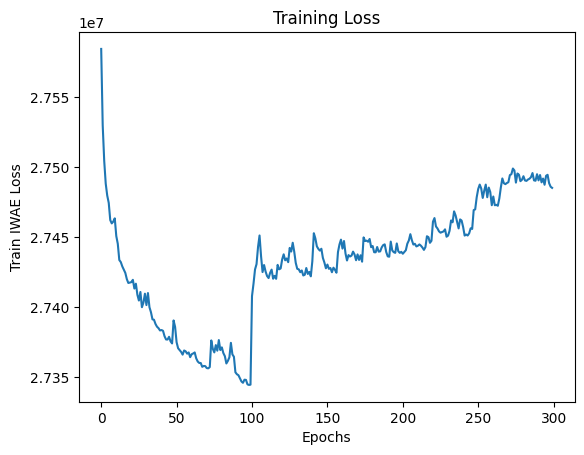

In [10]:
# plot training data 
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Train IWAE Loss')             
plt.savefig(os.path.join(output_folder, 'train_loss.png'))

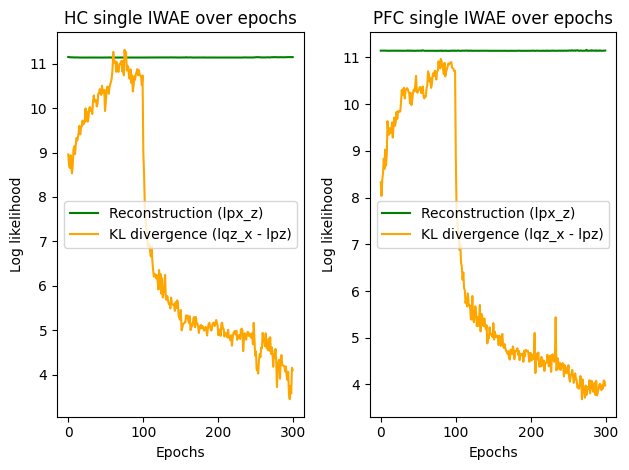

In [11]:
# plot individual loss functions from each encoder 
fig, ax = plt.subplots(1, 2)
for i, set in enumerate(dataset_abbrev):
    ax[i].plot(np.log(individual_loss[set]['lpx_z']), color='green', label='Reconstruction (lpx_z)')
    ax[i].plot(np.log(individual_loss[set]['kls']), color='orange', label='KL divergence (lqz_x - lpz)')
    ax[i].set_title(set + ' single IWAE over epochs')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log likelihood')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs_log.png'))

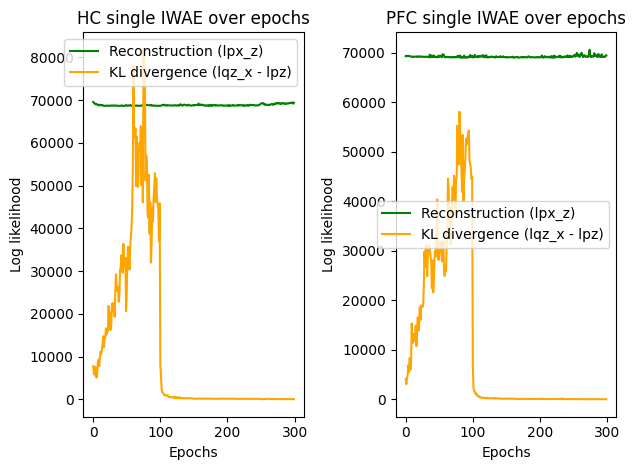

In [12]:
# plot individual loss functions from each encoder 
fig, ax = plt.subplots(1, 2)
for i, set in enumerate(dataset_abbrev):
    ax[i].plot((individual_loss[set]['lpx_z']), color='green', label='Reconstruction (lpx_z)')
    ax[i].plot((individual_loss[set]['kls']), color='orange', label='KL divergence (lqz_x - lpz)')
    ax[i].set_title(set + ' single IWAE over epochs')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Log likelihood')
    ax[i].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'individual_loss_graphs.png'))

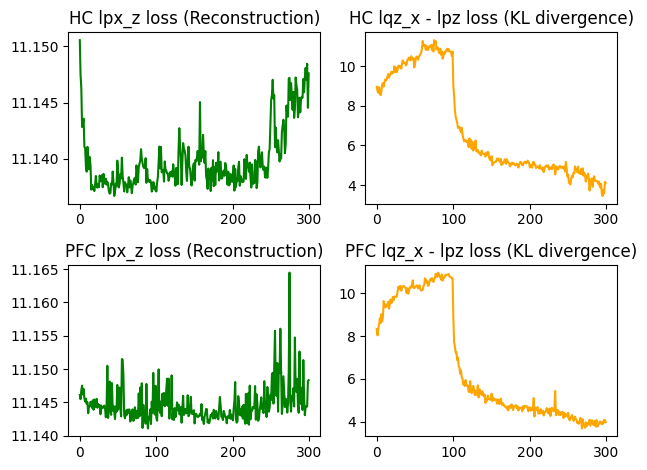

In [13]:
fig, ax = plt.subplots(2, 2)
for i, set in enumerate(dataset_abbrev):
    ax[i, 0].plot(np.log(individual_loss[set]['lpx_z']), color='green')
    ax[i, 0].set_title(set + ' lpx_z loss (Reconstruction)')
    ax[i, 1].plot(np.log(individual_loss[set]['kls']), color='orange')
    ax[i, 1].set_title(set + ' lqz_x - lpz loss (KL divergence)')
    plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_loss_graphs_log.png'))

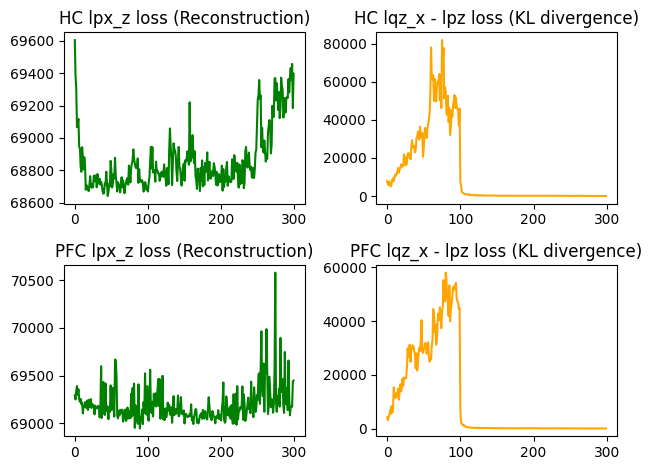

In [14]:
fig, ax = plt.subplots(2, 2)
for i, set in enumerate(dataset_abbrev):
    ax[i, 0].plot((individual_loss[set]['lpx_z']), color='green')
    ax[i, 0].set_title(set + ' lpx_z loss (Reconstruction)')
    ax[i, 1].plot((individual_loss[set]['kls']), color='orange')
    ax[i, 1].set_title(set + ' lqz_x - lpz loss (KL divergence)')
    plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_loss_graphs.png'))

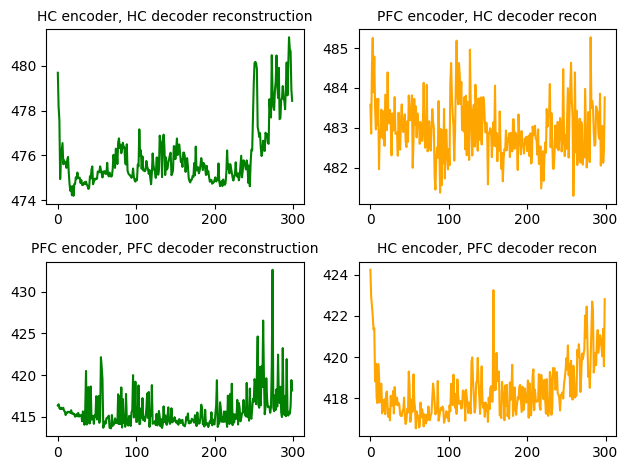

In [15]:
# Plotting each kind of reconstruction
fig, ax = plt.subplots(2, 2)
for i, set in enumerate(dataset_abbrev):
    ax[i, 0].plot((recon_loss[set][set]), color='green', label=f'{set} encoder')
    ax[i, 0].set_title(f'{set} encoder, {set} decoder reconstruction', fontsize=10)
    if i == 0:
        ax[i, 1].plot((recon_loss[dataset_abbrev[i+1]][set]), color='orange', label=f'{dataset_abbrev[i+1]} encoder')
        ax[i, 1].set_title(f'{dataset_abbrev[i+1]} encoder, {set} decoder recon', fontsize=10)
    else: 
        ax[i, 1].plot((recon_loss[dataset_abbrev[i-1]][set]), color='orange', label=f'{dataset_abbrev[i-1]} encoder')
        ax[i, 1].set_title(f'{dataset_abbrev[i-1]} encoder, {set} decoder recon', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'separate_recon_loss_graphs.png'))

Visualize latent space 

In [16]:
# choose hues that you want to plot
hues = ['cell_type', 'strain', 'encoder', '14-6-Bin']  # ['encoder', 'Diet', 'Label'] 

In [17]:
latent_space_1 = latent_space_1 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[0]}.csv'), index_col=False)
latent_space_2 = latent_space_2 = pd.read_csv(os.path.join(output_folder, f'latent_variables_epoch{epochs}_vae{dataset_abbrev[1]}.csv'), index_col=False)

In [18]:
latent_space_1.columns = latent_space_1.columns.str.replace(f'_{dataset_abbrev[0]}', '')
latent_space_2.columns = latent_space_2.columns.str.replace(f'_{dataset_abbrev[1]}', '')

In [19]:
latent_space_comb = pd.concat([latent_space_1, latent_space_2])
latent_space_comb = latent_space_comb.reset_index(drop=True)

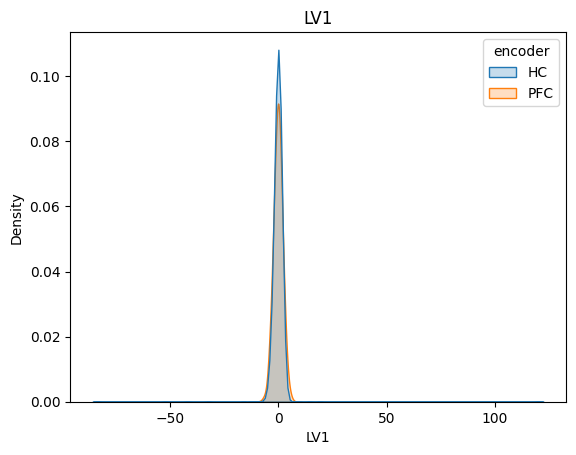

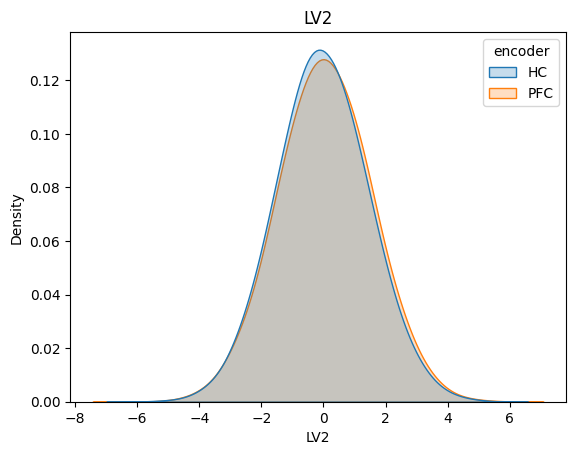

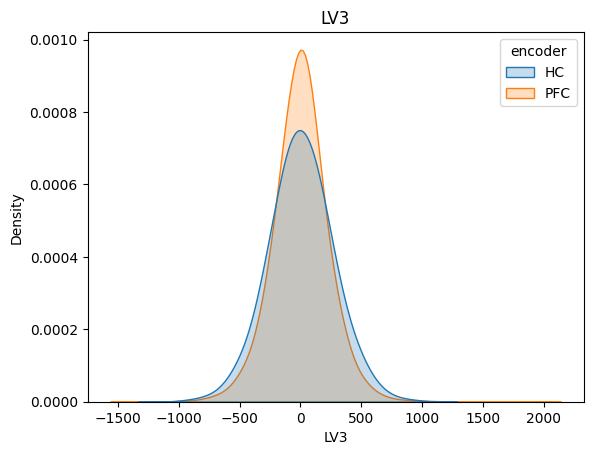

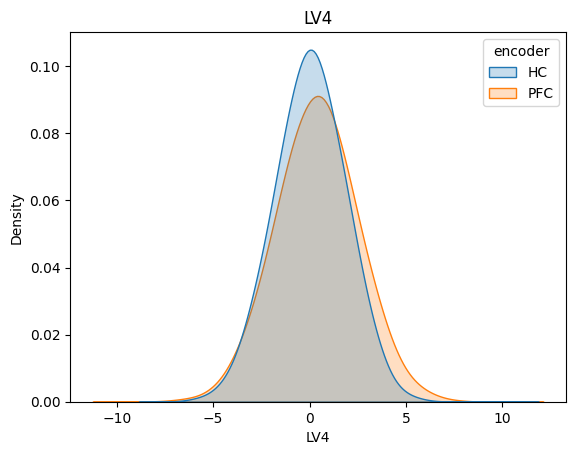

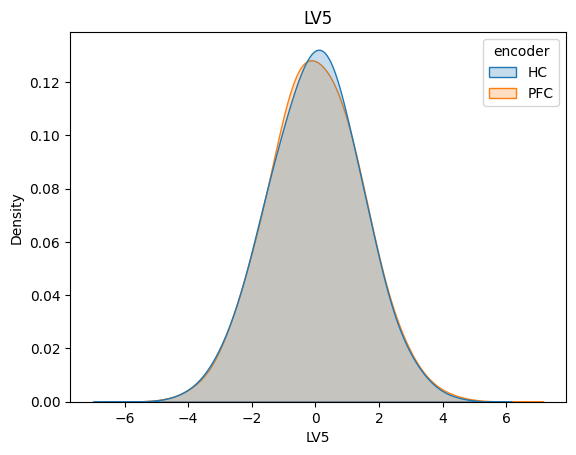

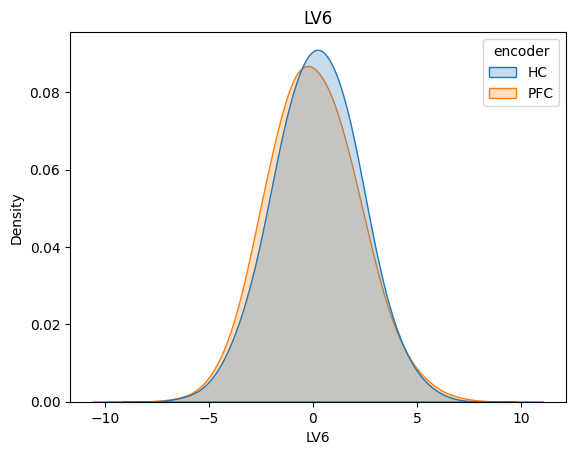

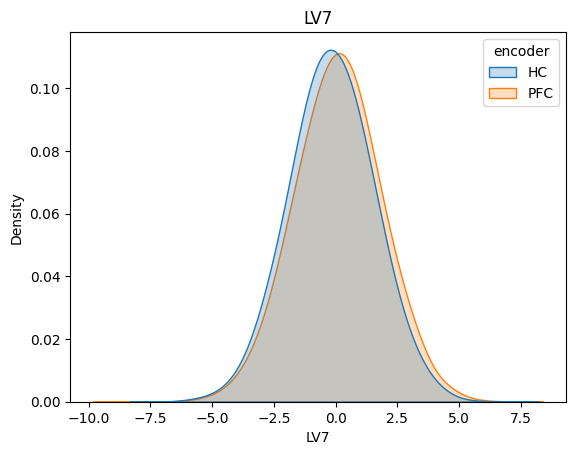

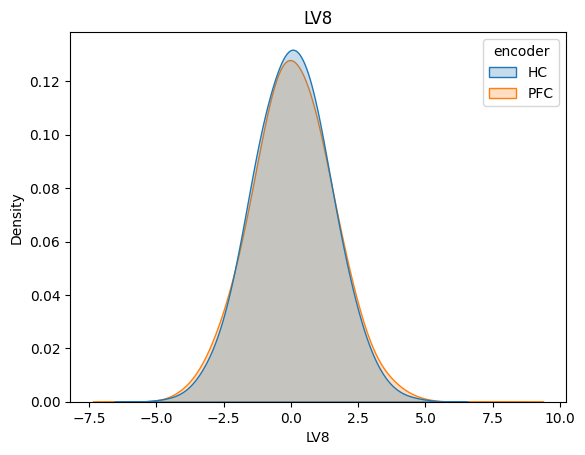

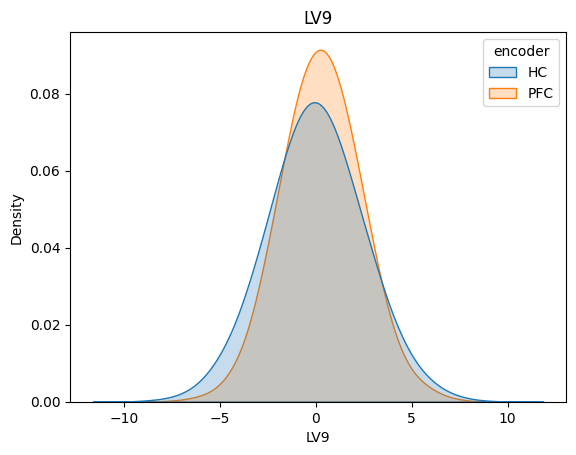

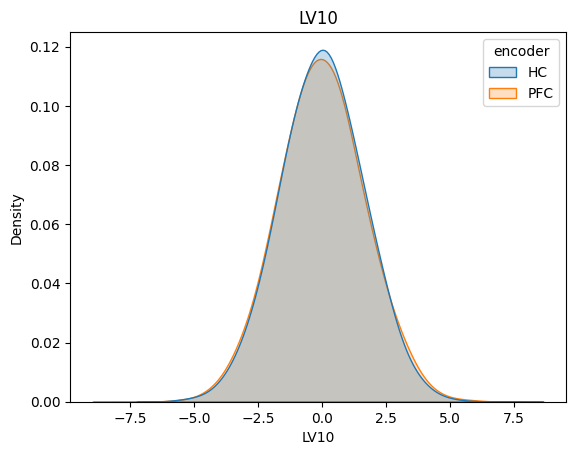

In [20]:
for column in latent_space_comb.columns[:latent_dim]:
    plt.figure()
    sns.kdeplot(data=latent_space_comb[[column, 'encoder']], x=column, hue='encoder', fill=True, bw_adjust=2)
    plt.title(column)

In [21]:
# make umap object 
reducer = umap.UMAP(n_neighbors=50, min_dist=1, n_components=2, random_state=random_seed)
embedding = reducer.fit_transform(latent_space_comb.iloc[:, :latent_dim])

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:
embedding_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
for hue in hues: 
    embedding_df[hue] = latent_space_comb[hue]

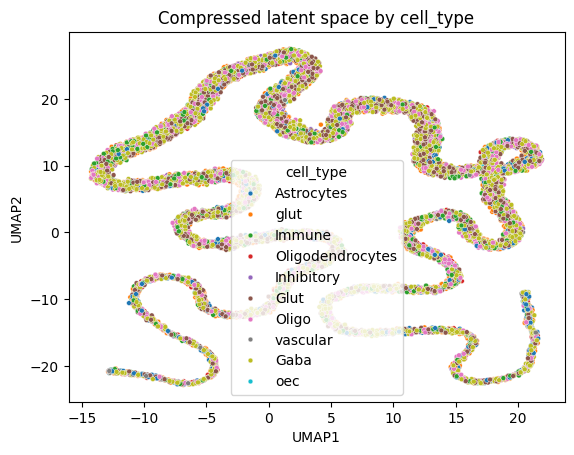

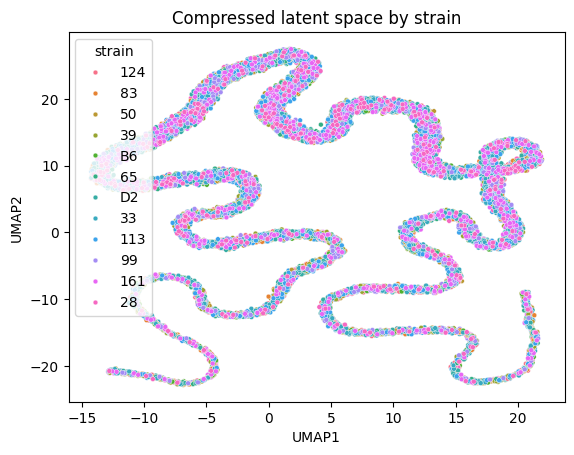

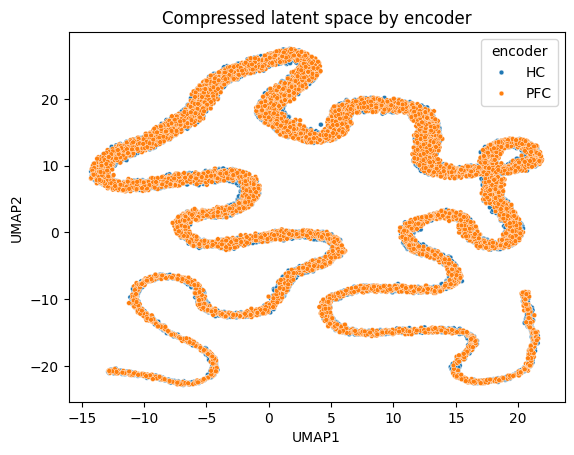

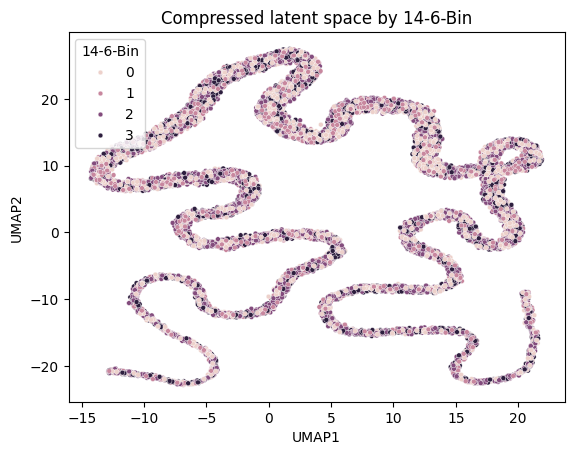

In [23]:
for hue in hues: 
    plt.figure()
    sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue, data=embedding_df, s=12)
    plt.title(f'Compressed latent space by {hue}')

In [24]:
embedding_df.to_csv(os.path.join(output_folder, 'latent_umap_embeddings.csv'))

In [25]:
raise StopIteration

StopIteration: 

Latent traversal 

In [ ]:
m1_var_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/HC30perc_var.csv' # '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/genoprobs_var.csv' 
m2_var_path = '/home/rachel/Desktop/mm-vae data/multiregion_adbxd_cr/PFC30perc_var.csv' # '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/physio_var.csv' 
if dataset == 'AD':
    latent_space_comb.rename(columns={'14-6-Bin': 'Label'}, inplace=True)

In [ ]:
dataset

'AD'

In [ ]:
m1_var = pd.read_csv(m1_var_path)
m2_var = pd.read_csv(m2_var_path)

In [ ]:
vae = torch.load(os.path.join(output_folder, f'saved_model_epoch{epoch}.pth'), map_location=device, weights_only=False)

In [ ]:
# function that takes a latent point, finds the count of the k nearest points, and returns the most popular label 
def find_label(all_latent_data, traversal_point, y, k=20):
    dist = torch.linalg.norm(all_latent_data - traversal_point.squeeze(0), dim=1)
    _, top_k_indices = torch.topk(dist, k, largest=False)
    label = torch.mode(y[top_k_indices]).values.item()
    return torch.tensor(label, dtype=torch.long)

In [ ]:
def latent_traversal(model, latent_data, device, traversal_dim, latent_dims, model_type, y, num_steps=10, latent_range=5, k=20): 
    model.eval()
    
    mean_latent_data = torch.Tensor(latent_data.iloc[:, :10].mean(axis=0).values.reshape(1, latent_dims))

    with torch.no_grad(): 
        num_samples = mean_latent_data.size(0)

        traversal_values = torch.linspace(-latent_range, latent_range, steps=num_steps)
        traversal_points = mean_latent_data.unsqueeze(0)

        var1_total = 0
        var2_total = 0

        for sample in range(num_samples):
            recon_m1comb = []
            recon_m2comb = []
            for i, z_val in enumerate(traversal_values): 
                z_step = traversal_points[:, sample, :].clone().reshape(1, 1, latent_dims)
                z_step[:, :, traversal_dim - 1] = z_val
                
                if model_type == 'VAE':
                    recon_m1, _ = model.vaes[0].decode(z_step.float()).to(device)
                    recon_m2, _ = model.vaes[1].decode(z_step.float()).to(device)
                elif model_type == 'CVAE':
                    label = find_label(torch.Tensor(latent_space_comb.iloc[:, :10].values), z_step, y, k)
                    recon_m1, _ = model.vaes[0].decode(z_step.float().to(device), label.to(device))
                    recon_m2, _ = model.vaes[1].decode(z_step.float().to(device), label.to(device))

                recon_m1comb.append(recon_m1)
                recon_m2comb.append(recon_m2)
    
            all_recons_m1 = torch.cat(recon_m1comb, dim=0)
            all_recons_m2 = torch.cat(recon_m2comb, dim=0)

            # feature_var1_norm = (torch.var(all_recons_m1, dim=0).cpu().numpy() / m1_var.T).squeeze()
            # feature_var2_norm = (torch.var(all_recons_m2, dim=0).cpu().numpy() / m2_var.T).squeeze()

            # no normalization
            feature_var1_norm = (torch.var(all_recons_m1, dim=0).cpu().numpy()).squeeze()
            feature_var2_norm = (torch.var(all_recons_m2, dim=0).cpu().numpy()).squeeze()

            var1_total += feature_var1_norm.mean().item()
            var2_total += feature_var2_norm.mean().item()
    return var1_total / num_samples, var2_total / num_samples

In [ ]:
std = latent_space_comb.iloc[:, :10].std(axis=0)
all_dims = list(range(1, latent_dim+1))
y = torch.Tensor(latent_space_comb['Label'].values).int()
for dim in all_dims: 
    print(f'Dimension of interest: {dim}')
    latent_range = 3 * std.iloc[dim-1]
    var1, var2 = latent_traversal(model, latent_space_comb, device, dim, latent_dim, model_type, y=y, num_steps=10, latent_range=latent_range, k=20)
    print(f'{dataset_abbrev[0]} variance: {var1}, {dataset_abbrev[1]} variance: {var2}')
    if var2 != 0.0:
        print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/var2}')
    else:
        print('Variance is 0.0')
        # print(f'Variance ratio ({dataset_abbrev[0]}/{dataset_abbrev[1]}): {var1/1e-15}')

Dimension of interest: 1
HC variance: 0.04768260195851326, PFC variance: 0.0457514189183712
Variance ratio (HC/PFC): 1.0422103420133841
Dimension of interest: 2
HC variance: 0.09775199741125107, PFC variance: 0.09793543070554733
Variance ratio (HC/PFC): 0.9981269976251212
Dimension of interest: 3
HC variance: 0.07257433235645294, PFC variance: 0.11456283926963806
Variance ratio (HC/PFC): 0.6334892956488283
Dimension of interest: 4
HC variance: 0.09378550201654434, PFC variance: 0.1620728075504303
Variance ratio (HC/PFC): 0.5786627839303777
Dimension of interest: 5
HC variance: 0.05961986258625984, PFC variance: 0.06469491869211197
Variance ratio (HC/PFC): 0.921554022967326
Dimension of interest: 6
HC variance: 0.09753531217575073, PFC variance: 0.1309797614812851
Variance ratio (HC/PFC): 0.7446594120549453
Dimension of interest: 7
HC variance: 0.03880186006426811, PFC variance: 0.027889806777238846
Variance ratio (HC/PFC): 1.3912559658152492
Dimension of interest: 8
HC variance: 0.0487

Quantifying latent dimension importance to reconstruction

In [ ]:
from sklearn.feature_selection import f_classif

In [ ]:
y_numpy = y.numpy()
F, _ = f_classif(latent_space_comb.iloc[:, :latent_dim], y)
latents_ordered = np.argsort(F)
latents_ordered

/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:106: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
latent_cols = latent_space_comb.iloc[:, :latent_dim].columns 
print('Latent feature variance correlations with cfc across both encoders')
for col in latents_ordered:
    print(f'{latent_cols[col]}: {F[col]}')

Latent feature variance correlations with cfc across both encoders
LV1: nan
LV2: nan
LV3: nan
LV4: nan
LV5: nan
LV6: nan
LV7: nan
LV8: nan
LV9: nan
LV10: nan


In [ ]:
rows1 = latent_space_comb['encoder'] == dataset_abbrev[0]

In [ ]:
latent_space_comb[rows1].iloc[:, :latent_dim]

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10
0,7.041544,3.060813,5.562575,-8.401187,-3.638375,-0.432601,0.225065,0.178300,1.919294,-8.436259
1,-0.038729,4.584506,-8.096614,-3.634217,1.165622,-0.829360,3.649839,-2.416988,-0.452315,5.757755
2,-5.008392,0.901215,3.542136,-2.597104,6.298467,10.519063,-0.730024,-5.371091,1.717522,7.058255
3,4.987272,4.551369,-4.362890,4.705458,-5.877736,-0.637130,2.844123,3.555313,0.934603,-3.256582
4,-1.253141,-1.501029,0.366518,-0.105457,1.515617,1.937582,1.207265,0.032231,0.543253,-0.575208
5,-1.435055,-4.269681,-4.352702,-5.984280,-3.509911,6.533369,-5.664343,-1.337904,-5.827289,-0.737083
6,1.388816,7.522478,-2.269968,-2.958039,-0.500033,5.695357,-2.172146,-2.286052,7.522231,0.105568
7,-1.793378,-0.281392,1.196489,3.398877,1.728578,-2.139766,1.862896,-1.885733,0.990919,-1.579942
8,-8.217008,8.215934,4.073503,6.708323,3.753405,1.884690,4.106732,-3.956775,-3.608341,2.075469
9,-1.714564,6.516642,3.567378,-1.049996,-4.266015,5.808084,2.269903,2.224675,-4.137372,-0.450334


In [ ]:
F_1, _ = f_classif(latent_space_comb[rows1].iloc[:, :latent_dim], y[rows1])
latents_ordered_1 = np.argsort(F_1)
print(f'Latent feature variance correlations with cfc from {dataset_abbrev[0]} encoder')
for col in latents_ordered_1:
    print(f'{latent_cols[col]}: {F_1[col]}')

F_2, _ = f_classif(latent_space_comb[~rows1].iloc[:, :latent_dim], y[~rows1])
latents_ordered_2 = np.argsort(F_2)
print(f'Latent feature variance correlations with cfc from {dataset_abbrev[1]} encoder')
for col in latents_ordered_2:
    print(f'{latent_cols[col]}: {F_2[col]}')

Latent feature variance correlations with cfc from HC encoder
LV1: nan
LV2: nan
LV3: nan
LV4: nan
LV5: nan
LV6: nan
LV7: nan
LV8: nan
LV9: nan
LV10: nan
Latent feature variance correlations with cfc from PFC encoder
LV1: nan
LV2: nan
LV3: nan
LV4: nan
LV5: nan
LV6: nan
LV7: nan
LV8: nan
LV9: nan
LV10: nan


/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:106: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
/home/rachel/miniforge3/envs/mm-vae/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:106: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)


MLP classifier to evaluate conditioning

In [ ]:
# extra imports I need to make
from simple_mlp import*
from mlp_databuilder import*
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
# initialize MLP config parameters 
mlp_epochs = 100
mlp_learning_rate = 1e-3
mlp_batch_size = 128

# mlp parameters 
input_size = latent_dim
hidden_size = latent_dim * 2

In [ ]:
if dataset == 'DO_cfc':
    # make latent df with continuous cfc as the label 
    latent_df = pd.merge(latent_space_comb[list(latent_cols) + ['MouseID']], paired_df[['MouseID', 'CFC.24mo.Average']], on='MouseID')
    train_df, test_df = train_test_split(latent_df, test_size=0.2, random_state=random_seed)
    train_dataset = MLPDataBuilder(train_df, latent_cols, 'CFC.24mo.Average')
    train_loader = DataLoader(train_dataset, batch_size=mlp_batch_size, shuffle=True)
    test_dataset = MLPDataBuilder(test_df, latent_cols, 'CFC.24mo.Average')
    test_loader = DataLoader(test_dataset, batch_size=mlp_batch_size, shuffle=True)
else: 
    latent_df = latent_space_comb[list(latent_cols) + ['Label']]
    train_df, test_df = train_test_split(latent_df, test_size=0.2, random_state=random_seed)
    train_dataset = MLPDataBuilder(train_df, latent_cols, 'Label')
    train_loader = DataLoader(train_dataset, batch_size=mlp_batch_size, shuffle=True)
    test_dataset = MLPDataBuilder(test_df, latent_cols, 'Label')
    test_loader = DataLoader(test_dataset, batch_size=mlp_batch_size, shuffle=True)

In [ ]:
model = simple_mlp(latent_dim=latent_dim, hidden_dim=hidden_size).to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=mlp_learning_rate)
#optimizer = optim.Adam(model.parameters(), lr=mlp_learning_rate, weight_decay=1e-4)

In [ ]:
# train the model
train_losses = []
test_losses = []
end_outputs = []
end_labels = []
for epoch in range(mlp_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, labels.unsqueeze(1))

        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    print(f'Epoch [{epoch+1}/{mlp_epochs}], Loss: {train_loss / len(train_loader):.8f}')

    train_losses.append(train_loss / len(train_loader))

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_idx, (data,labels) in enumerate(test_loader):
            data = data.to(device)
            labels = labels.to(device)
            output = model(data)
            loss = criterion(output, labels.unsqueeze(1))
            test_loss += loss.item()
            if epoch+1 == mlp_epochs:
                end_outputs.append(output)
                end_labels.append(labels)
    
    test_losses.append(test_loss / len(test_loader))

end_outputs_comb = torch.cat(end_outputs).flatten().detach().cpu().numpy()
end_labels_comb = torch.cat(end_labels).flatten().detach().cpu().numpy()
end_combined = {
    'true_label': end_labels_comb, 
    'predicted_labels': end_outputs_comb
}
pd.DataFrame(end_combined).to_csv(os.path.join(output_folder, 'pred_vs_true.csv'), index=False)
print('Predicted versus true labels saved')

Epoch [1/100], Loss: 0.13997471
Epoch [2/100], Loss: 0.13655464
Epoch [3/100], Loss: 0.13321941
Epoch [4/100], Loss: 0.12996706
Epoch [5/100], Loss: 0.12679572
Epoch [6/100], Loss: 0.12370355
Epoch [7/100], Loss: 0.12068871
Epoch [8/100], Loss: 0.11774935
Epoch [9/100], Loss: 0.11488371
Epoch [10/100], Loss: 0.11208999
Epoch [11/100], Loss: 0.10936639
Epoch [12/100], Loss: 0.10671121
Epoch [13/100], Loss: 0.10412270
Epoch [14/100], Loss: 0.10159916
Epoch [15/100], Loss: 0.09913887
Epoch [16/100], Loss: 0.09674023
Epoch [17/100], Loss: 0.09440160
Epoch [18/100], Loss: 0.09212135
Epoch [19/100], Loss: 0.08989795
Epoch [20/100], Loss: 0.08772986
Epoch [21/100], Loss: 0.08561561
Epoch [22/100], Loss: 0.08355375
Epoch [23/100], Loss: 0.08154288
Epoch [24/100], Loss: 0.07958166
Epoch [25/100], Loss: 0.07766882
Epoch [26/100], Loss: 0.07580303
Epoch [27/100], Loss: 0.07398311
Epoch [28/100], Loss: 0.07220788
Epoch [29/100], Loss: 0.07047620
Epoch [30/100], Loss: 0.06878699
Epoch [31/100], Los

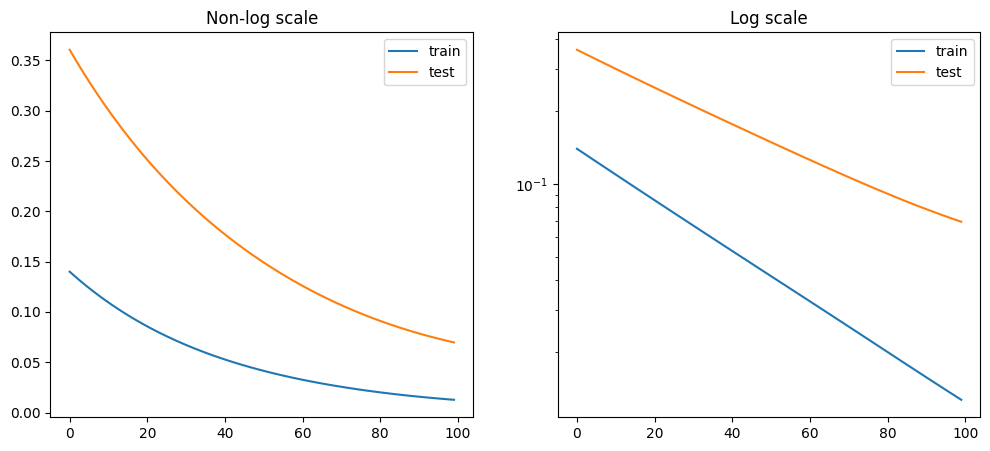

In [ ]:
# print the training and testing loss results 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses, label='train')
ax[0].plot(test_losses, label='test')
ax[0].set_title('Non-log scale')
ax[0].legend()
ax[1].plot(train_losses, label='train')
ax[1].plot(test_losses, label='test')
ax[1].set_title('Log scale')
ax[1].legend()
ax[1].set_yscale('log')
plt.savefig(os.path.join(output_folder, 'mlp_train_and_test_loss.png'))

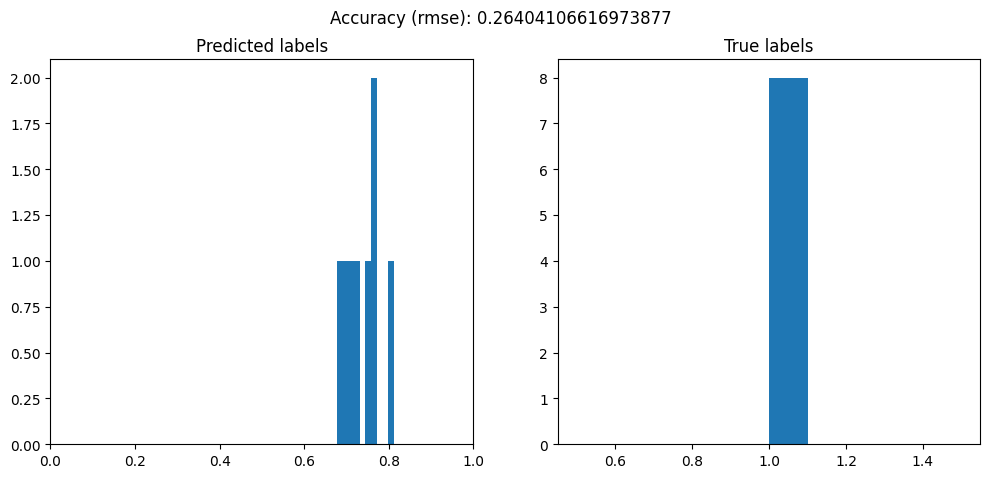

In [ ]:
#  plot distribution of predicted versus true labels 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(end_outputs_comb)
ax[0].set_title('Predicted labels')
ax[0].set_xlim(0, np.max(end_labels_comb))
ax[1].hist(end_labels_comb)
ax[1].set_title('True labels')
fig.suptitle(f'Accuracy (rmse): {root_mean_squared_error(end_outputs_comb, end_labels_comb)}')
plt.savefig(os.path.join(output_folder, 'pred_vs_.png'))